# Step 3: 5-second ECG Segmentation

This notebook uses the cleaned sit-only ECG data from Step 2 to generate fixed 5-second ECG segments without overlap and without zero padding.


In [2]:
# Cell 1: paths and imports

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
# project root
PROJECT_ROOT = Path(r"F:\ECG")

# cleaned data are stored under data/processed
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Step 3 input files: sit-only cleaned metadata and signals
METADATA_INPUT_PATH = PROCESSED_DIR / "metadata_sit_clean.csv"
SIGNALS_INPUT_PATH = PROCESSED_DIR / "signals_sit_clean.pkl"

# Step 3 output files
SEGMENT_METADATA_OUTPUT_PATH = PROCESSED_DIR / "segment_metadata_sit_5s.csv"
X_OUTPUT_PATH = PROCESSED_DIR / "X_segments_sit_5s.npy"
Y_OUTPUT_PATH = PROCESSED_DIR / "y_segments_sit_5s.npy"

# Sampling rate: UofT ECG Database ECG recordings use 200 Hz
fs = 200

# 5-second non-overlapping windows
window_seconds = 5
segment_length = window_seconds * fs  # 5 * 200 = 1000 samples

print("input metadata:", METADATA_INPUT_PATH)
print("input signals PKL:", SIGNALS_INPUT_PATH)
print("output segment metadata:", SEGMENT_METADATA_OUTPUT_PATH)
print("output X:", X_OUTPUT_PATH)
print("output y:", Y_OUTPUT_PATH)
print("segment_length:", segment_length)

input metadata: F:\ECG\data\processed\metadata_sit_clean.csv
input signals PKL: F:\ECG\data\processed\signals_sit_clean.pkl
output segment metadata: F:\ECG\data\processed\segment_metadata_sit_5s.csv
output X: F:\ECG\data\processed\X_segments_sit_5s.npy
output y: F:\ECG\data\processed\y_segments_sit_5s.npy
segment_length: 1000


In [4]:
# Cell 2: load sit-only cleaned metadata and signal PKL

# the CSV stores descriptive information for each recording and does not store full ECG waveforms
metadata_sit_clean = pd.read_csv(METADATA_INPUT_PATH)

# the PKL stores the actual ECG signals in the format:signals_sit_clean[record_number] = ECG array
with open(SIGNALS_INPUT_PATH, "rb") as f:
    signals_sit_clean = pickle.load(f)

# record_number links CSV rows to PKL keys; keep it as int
metadata_sit_clean["record_number"] = metadata_sit_clean["record_number"].astype(int)
signals_sit_clean = {int(record_number): signal for record_number, signal in signals_sit_clean.items()}

print("metadata_sit_clean shape:", metadata_sit_clean.shape)
print("signals_sit_clean count:", len(signals_sit_clean))


metadata_sit_clean shape: (1288, 15)
signals_sit_clean count: 1288


,record_number,subject_id,week_number,condition_number,condition_name,signal_length_samples,duration_seconds,signal_index_path,is_valid,invalid_reason,raw_signal_length_samples,raw_duration_seconds,cleaned_signal_length_samples,cleaned_duration_seconds,expected_5s_segments
0,1,1,1,1,sit,24001,120.005,"signals[0,0][week=0][condition=0]",True,valid,24001,120.005,24001,120.005,24
1,2,2,1,1,sit,24001,120.005,"signals[0,1][week=0][condition=0]",True,valid,24001,120.005,24001,120.005,24
2,3,3,1,1,sit,24001,120.005,"signals[0,2][week=0][condition=0]",True,valid,24001,120.005,24001,120.005,24
3,4,4,1,1,sit,24001,120.005,"signals[0,3][week=0][condition=0]",True,valid,24001,120.005,24001,120.005,24
4,5,5,1,1,sit,24001,120.005,"signals[0,4][week=0][condition=0]",True,valid,24001,120.005,24001,120.005,24


In [6]:
# Cell 3: check whether metadata record_number values are fully synchronized with PKL keys

required_columns = [
    "record_number",
    "subject_id",
    "week_number",
    "condition_number",
    "condition_name",
]

# Check metadata synchronization
missing_columns = [column for column in required_columns if column not in metadata_sit_clean.columns]
if missing_columns:
    raise ValueError(f"metadata is missing required columns: {missing_columns}")

# Check record_number uniqueness
duplicate_count = metadata_sit_clean["record_number"].duplicated().sum()

# Compare CSV record_number values with PKL keys
metadata_record_numbers = set(metadata_sit_clean["record_number"])
pkl_record_numbers = set(signals_sit_clean.keys())

missing_in_pkl = sorted(metadata_record_numbers - pkl_record_numbers)
extra_in_pkl = sorted(pkl_record_numbers - metadata_record_numbers)

is_synced = (duplicate_count == 0) and (len(missing_in_pkl) == 0) and (len(extra_in_pkl) == 0)

print("metadata record_number count:", len(metadata_record_numbers))
print("PKL key count:", len(pkl_record_numbers))
print("duplicate metadata record_number count:", duplicate_count)
print("metadata rows missing from PKL record_number keys:", len(missing_in_pkl))
print("PKL keys missing from metadata:", len(extra_in_pkl))
print("record_number values match PKL keys:", is_synced)

if not is_synced:
    raise ValueError("metadata_sit_clean.csv and signals_sit_clean.pkl are not aligned. Please rerun Step 2.")

metadata record_number count: 1288
PKL key count: 1288
duplicate metadata record_number count: 0
metadata rows missing from PKL record_number keys: 0
PKL keys missing from metadata: 0
record_number values match PKL keys: True


In [8]:
# Cell 4: split each ECG signal into 5-second non-overlapping segments

segment_metadata_rows = []
X_segments_list = []
y_segments_list = []

# segment_id is the unique identifier for each segment and starts from 0
segment_id = 0

# process ECG recordings one by one in metadata order
for _, row in metadata_sit_clean.iterrows():
    record_number = int(row["record_number"])
    subject_id = int(row["subject_id"])
    week_number = int(row["week_number"])
    condition_number = int(row["condition_number"])
    condition_name = row["condition_name"]

    # extract the ECG signal for this recording
    signal = np.asarray(signals_sit_clean[record_number]).squeeze()

    # ECG shape is normalized before segmentation.
    if signal.ndim != 1:
        raise ValueError(f"record_number={record_number} signal is not a one-dimensional array; actual shape={signal.shape}")

    # Skip recordings shorter than 5 seconds.
    # Use floor division to keep complete 1000-sample windows.
    num_segments_this_record = len(signal) // segment_length

    for segment_index in range(num_segments_this_record):
        start_sample = segment_index * segment_length
        end_sample = start_sample + segment_length

        # Python slicing is left-closed and right-open:signal[start_sample:end_sample]
        # Slice 0:1000 includes samples 0 to 999 for the first segment.
        segment = signal[start_sample:end_sample]

        X_segments_list.append(segment)
        y_segments_list.append(subject_id)

        segment_metadata_rows.append({
            "segment_id": segment_id,
            "record_number": record_number,
            "subject_id": subject_id,
            "week_number": week_number,
            "condition_number": condition_number,
            "condition_name": condition_name,
            "segment_index_within_record": segment_index,
            "start_sample": start_sample,
            "end_sample": end_sample,
            "start_time_seconds": start_sample / fs,
            "end_time_seconds": end_sample / fs,
        })

        segment_id += 1

# convert to NumPy arrays commonly used by later models
X_segments = np.stack(X_segments_list, axis=0)
y_segments = np.array(y_segments_list)
segment_metadata = pd.DataFrame(segment_metadata_rows)

print("segmentation complete.")
print("X_segments shape:", X_segments.shape)
print("y_segments shape:", y_segments.shape)
print("segment_metadata shape:", segment_metadata.shape)

segmentation complete.
X_segments shape: (36103, 1000)
y_segments shape: (36103,)
segment_metadata shape: (36103, 11)


In [16]:
# Cell 5: save Step 3 outputs

# save ECG segments and labels used by the model
np.save(X_OUTPUT_PATH, X_segments)
np.save(Y_OUTPUT_PATH, y_segments)

# save source information for each segment so it can be traced back to the original recording
segment_metadata.to_csv(SEGMENT_METADATA_OUTPUT_PATH, index=False)

print("Saved files:")
print("segment metadata:", SEGMENT_METADATA_OUTPUT_PATH)
print("X segments:", X_OUTPUT_PATH)
print("y segments:", Y_OUTPUT_PATH)
display(segment_metadata.head(10))

print("X_segments shape:", X_segments.shape)
print("y_segments shape:", y_segments.shape)

for i in range(10):
    print(f"\nSegment {i}")
    print("Label / subject_id:", y_segments[i])
    print("first 20 ECG samples:", X_segments[i][:20])

Saved files:
segment metadata: F:\ECG\data\processed\segment_metadata_sit_5s.csv
X segments: F:\ECG\data\processed\X_segments_sit_5s.npy
y segments: F:\ECG\data\processed\y_segments_sit_5s.npy


,segment_id,record_number,subject_id,week_number,condition_number,condition_name,segment_index_within_record,start_sample,end_sample,start_time_seconds,end_time_seconds
0,0,1,1,1,1,sit,0,0,1000,0.0,5.0
1,1,1,1,1,1,sit,1,1000,2000,5.0,10.0
2,2,1,1,1,1,sit,2,2000,3000,10.0,15.0
3,3,1,1,1,1,sit,3,3000,4000,15.0,20.0
4,4,1,1,1,1,sit,4,4000,5000,20.0,25.0
5,5,1,1,1,1,sit,5,5000,6000,25.0,30.0
6,6,1,1,1,1,sit,6,6000,7000,30.0,35.0
7,7,1,1,1,1,sit,7,7000,8000,35.0,40.0
8,8,1,1,1,1,sit,8,8000,9000,40.0,45.0
9,9,1,1,1,1,sit,9,9000,10000,45.0,50.0


X_segments shape: (36103, 1000)
y_segments shape: (36103,)

Segment 0
Label / subject_id: 1
first 20 ECG samples: [-0.41220104 -0.37026478  0.30970173 -0.21450153 -0.43916007  0.10900677
  0.05209327 -0.38224657  0.00716157  0.51638759 -0.21749697 -0.07671096
  0.6122419  -0.12164266 -0.36127844  0.25278824  0.07605685 -0.41519649
  0.00716157  0.42951962]

Segment 1
Label / subject_id: 1
first 20 ECG samples: [-0.30736039 -0.0287838   0.51638759 -0.20551519 -0.21450153  0.51638759
  0.07006596 -0.25643779  0.26776547  0.38758336 -0.23247421  0.04610238
  0.54334662 -0.20251974 -0.14860169  0.720078    0.18389295 -0.19652884
  0.39956515  0.32467897]

Segment 2
Label / subject_id: 1
first 20 ECG samples: [-0.48708722  0.07006596  0.49541946 -0.36726934 -0.26242868  0.52836938
 -0.22348787 -0.43017373  0.2947245   0.0730614  -0.50505991 -0.04975193
  0.33366531 -0.43017373 -0.244456    0.6122419  -0.12164266 -0.37026478
  0.37560157  0.16891572]

Segment 3
Label / subject_id: 1
first 20

In [20]:
# Cell 6: print summary and check whether segmentation results are reasonable

week_segment_counts = segment_metadata.groupby("week_number").size().sort_index()
subject_segment_counts = segment_metadata.groupby("subject_id").size().sort_index()

print("========== Step 3 Summary ==========")
print("input sit clean record count:", len(metadata_sit_clean))
print("total generated segments:", len(segment_metadata))
print("X shape:", X_segments.shape)
print("y shape:", y_segments.shape)
print("unique subject count:", len(np.unique(y_segments)))

print("\nsegment count per week:")
print(week_segment_counts)

print("\nsegment count statistics per subject:")
print(subject_segment_counts.describe())

print("\nmetadata for the first five segments:")
display(segment_metadata.head())

========== Step 3 Summary ==========
input sit clean record count: 1288
total generated segments: 36103
X shape: (36103, 1000)
y shape: (36103,)
unique subject count: 1019

segment count per week:
week_number
1    25555
2     1728
3     1824
4     3480
6     3516
dtype: int64

segment count statistics per subject:
count    1019.000000
mean       35.429833
std        39.869923
min         5.000000
25%        12.000000
50%        24.000000
75%        36.000000
max       240.000000
dtype: float64

metadata for the first five segments:


,segment_id,record_number,subject_id,week_number,condition_number,condition_name,segment_index_within_record,start_sample,end_sample,start_time_seconds,end_time_seconds
0,0,1,1,1,1,sit,0,0,1000,0.0,5.0
1,1,1,1,1,1,sit,1,1000,2000,5.0,10.0
2,2,1,1,1,1,sit,2,2000,3000,10.0,15.0
3,3,1,1,1,1,sit,3,3000,4000,15.0,20.0
4,4,1,1,1,1,sit,4,4000,5000,20.0,25.0


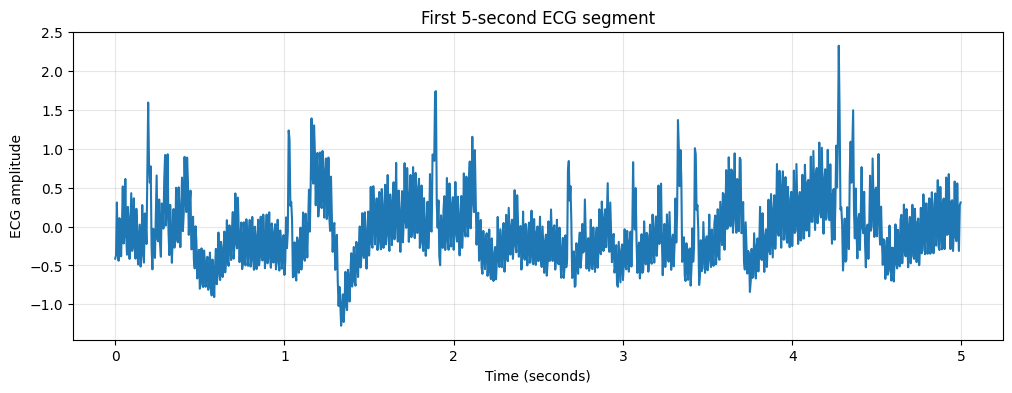

In [22]:
# Cell 7: plot the waveform of the first 5-second ECG segment

import matplotlib.pyplot as plt

first_segment = X_segments[0]
time_axis = np.arange(segment_length) / fs

plt.figure(figsize=(12, 4))
plt.plot(time_axis, first_segment)
plt.title("First 5-second ECG segment")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG amplitude")
plt.grid(True, alpha=0.3)
plt.show()